# Lasso (classification) Hyperparameter Tuning Using Mother

In this example we will outline how easy another ML algorithm can be used as a base model for hyperparameter tuning. At this stage, 3 different algorithms are supported within mother out of the box. However, as you can see in the 'models' folder, it is very easy to provide additional models very easily.

In [1]:
from pathlib import Path
import logging
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import make_scorer, matthews_corrcoef


import mother.ml as ml
import mother.optimization as opt
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

# Ensure plots are displayed inline
%matplotlib inline
logging.basicConfig(level=logging.INFO)

In [2]:
ml.get_available_algorithms()

['randomforest', 'catboost', 'lasso']

In [3]:
print(*ml.get_supported_models(), sep=" -- ")

RandomForestClassifierMother -- RandomForestRegressorMother -- CatboostClassifierMother -- CatboostGaussianProcessRegressorMother -- CatboostRegressorMother -- LassoClassifierBinaryMother -- LassoClassifierMulticlassMother -- LassoRegressorMother


In [4]:
selected_model: str = "LassoClassifierBinaryMother"

In [5]:
print(ml.describe_model(selected_model))

## LassoClassifierBinaryMother

MOTHER class for a LASSO classification including hyperparameter optimization

### get_hyperparameter_space

Define the hyperparameter search space for Lasso classification.

Parameters:
    X: array-like
        Feature matrix.
    y: array-like
        Target vector.
    trial: optuna.trial.Trial
        Optuna trial object for suggesting hyperparameters.
    prefix: str, optional
        Prefix to add to hyperparameter names.

Returns:
    dict: Dictionary containing hyperparameter names and their suggested values.

### default_parameters

Return the default hyperparameters for the Lasso model.

Parameters:
    prefix: str, optional
        Prefix to add to hyperparameter names.

Returns:
    dict: Dictionary containing default hyperparameter values.

For more information on the parent class just use 'help(ml.get_model_class("LassoClassifierBinaryMother")'


In [6]:
ml.get_model_class(selected_model)

mother.ml.models.m_lasso.LassoClassifierBinaryMother

### Import Data
Load the data from the input file and limit the data to 100 rows for testing purposes.
The data file contains a column with the molecular structure (__Molecule__) and a column with the target value (__expt__).



In [7]:
input_file: Path = Path("../compounds_class_1.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
# data = data.head(100)  # limit data to 100 rows for testing
data = data[["name", "smiles", "p_np"]]
data.head()

,name,smiles,p_np
0,"""1,1,1-Trifluro-2-chloroethane""",FC(F)(F)CCl,1
1,111-trichloroethane,CC(Cl)(Cl)Cl,1
2,111-trifluoro-2-chloroethane,FC(F)(F)CCl,1
3,2-Methylpentane,CCCC(C)C,1
4,3-methylhexane,CCCC(C)CC,1


<Axes: xlabel='p_np', ylabel='Count'>

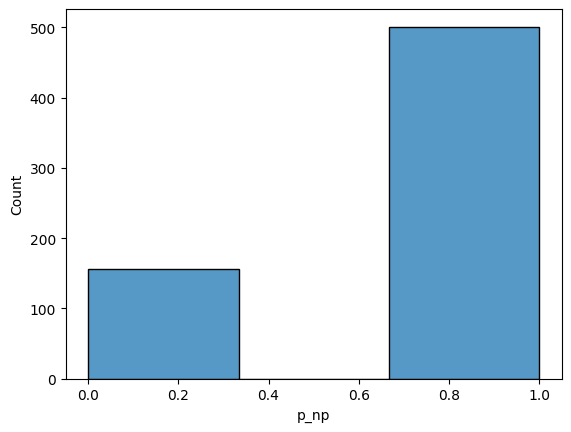

In [8]:
import seaborn as sns

sns.histplot(data=data, x="p_np", bins=3)

In [9]:
len(data)

657

## Preprocessing
The preprocessing pipeline consists of two steps:
1. Standardize the molecular structure using the __StandardizerTransformer__.
2. Convert the standardized SMILES to a molecule object using the __SmilesToMolTransformer__.

In [10]:
preprocessor: sklearn_pipeline.Pipeline = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
        # Add other column transformations here if needed
    ],
    memory=None,
).set_output(transform="pandas")  # type: ignore

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data)  # type: ignore

mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[11:08:00] Initializing Normalizer
[11:08:00] Initializing Normalizer
[11:08:00] Initializing MetalDisconnector
[11:08:00] Initializing Normalizer
ERROR:mother.preprocessing.core:Catched exception
Traceback (most recent call last):
  File "/workspaces/mother-ml/mother/preprocessing/core.py", line 71, in _transform
    with m_chem.RaiseRDKitErrors():
  File "/workspaces/mother-ml/mother/chem.py", line 104, in __exit__
    raise RDKitException(self.clean_error_msg(stderr))
mother.chem.RDKitException: Running MetalDisconnector Running FragmentRemover Running LargestFragmentChooser Running Uncharger Running Normalizer Can't kekulize mol.  Unkekulized atoms: 12 15 FAILED sanitizeMol.


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x7d5675825070>
1,<rdkit.Chem.rdchem.Mol object at 0x7d5675824f90>
2,<rdkit.Chem.rdchem.Mol object at 0x7d5675825fc0>
3,<rdkit.Chem.rdchem.Mol object at 0x7d5675824b30>
4,<rdkit.Chem.rdchem.Mol object at 0x7d5675825c40>


In [11]:
print(mol_data.shape)
mol_data.dropna(subset="Molecule", inplace=True, axis=0)
print(mol_data.shape)

(657, 1)
(657, 1)


## Feature Generation
By combining multiple feature generators, we can create a feature matrix that contains various types of features. By default, we are combining _MACCS_ fingerprints, _Morgan_ fingerprints, and _Chemical Descriptors_.

In [12]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("maccs", fg.MaccsFingerprints()),
        ("morgan", fg.MorganFingerprints()),
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")


features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"])

features.head()

INFO:mother.feature_generation.core:Calculating MACCS fingerprints
INFO:mother.feature_generation.core:Calculating MorganFP fingerprints using parameters: {'radius': 2, 'fpSize': 1024, 'includeChirality': False}
INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'


,maccs__maccs_0,maccs__maccs_1,maccs__maccs_2,maccs__maccs_3,maccs__maccs_4,maccs__maccs_5,maccs__maccs_6,maccs__maccs_7,maccs__maccs_8,maccs__maccs_9,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Grouping for Cross-Validation
To ensure that the training and validation sets do not contain similar molecules, we group the molecules based on their similarity. We use the Tanimoto similarity to group molecules with a similarity threshold of 0.7. 

In [13]:
# cv grouping
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)

groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"])

# cv = StratifiedGroupKFold(n_splits=5)
cv = GroupKFold(n_splits=5)

print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 274 clusters


274 groups found


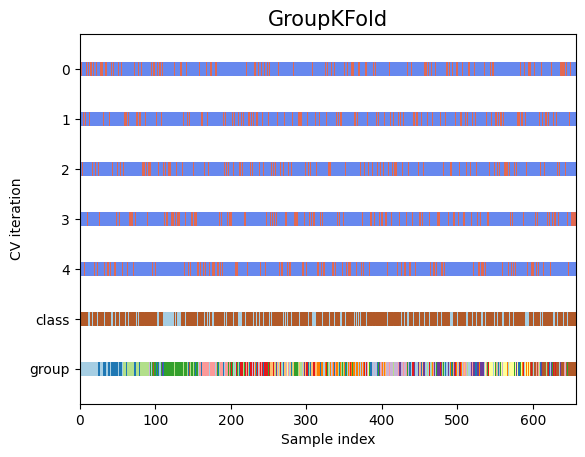

In [14]:
from mother.cv import report as cv_report

cv_report.plot_cv_indices(cv=cv, X=features, y=data["p_np"], group=groups["tanimoto-group"], n_splits=5)

## Model Training
The model consists of two steps:
1. Feature selection using the __FeatureSelector__
2. Model training using the __LassoClassifierBinaryMother__

In [24]:
from mother.ml.models.m_lasso import LassoClassifierBinaryMother
from sklearn.preprocessing import StandardScaler

model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES"],
    "feature_selection_threshold": 1e-5,
    "correlation_threshold": 0.9,
    "algorithm": "lasso",
    "feature_selection_type": "catboost",
}
pipeline_settings = {
    "remainder": "passthrough",
    "verbose_feature_names_out": False,
}
model_settings["model_type"] = "classification"
model_settings["target_type"] = "single_target"
# lasso parameters
model_settings["parameters"] = {
    "C": 1,  # Regularization strength
    "max_iter": 3000,  # Maximum number of iterations for convergence
    "tol": 1e-4,  # Tolerance for stopping criteria
    "solver": "liblinear",  # 'saga' is suitable for L1_penalty and complex
    "n_jobs": 6,
}

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings, pipeline_settings=pipeline_settings
            ),
        ),
        ("scaler", StandardScaler()),
        ("ml_model", LassoClassifierBinaryMother(**model_settings["parameters"])),
    ]
).set_output(transform="pandas")

# fit the model to data
model.fit(features, data["p_np"])

targets_pred = model.predict(features)

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(


In [25]:
# compare the predicted values with the experimental values
pd.concat((data["p_np"], pd.Series(targets_pred, name="p_np_pred")), axis=1)

,p_np,p_np_pred
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
652,1,1
653,1,1
654,1,1
655,1,1


In [26]:
%matplotlib inline

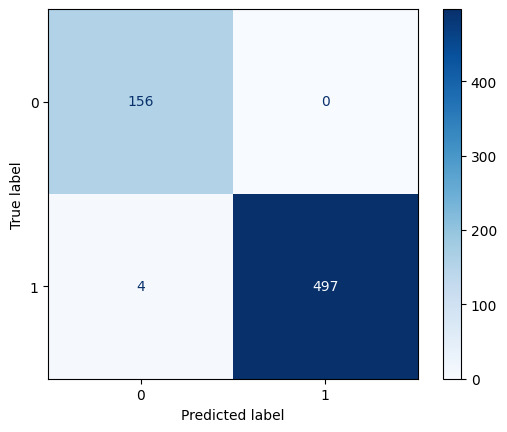

In [27]:
# import matplotlib
# matplotlib.use("TkAgg")
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plt.cla()
import seaborn as sns

sns.reset_defaults()
y_true = data["p_np"]
y_pred = model.predict(features)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

In [28]:
from sklearn import metrics


def calc_metrics(labels_test, test_probs, threshold=0.5):
    scores = [1 if x >= threshold else 0 for x in test_probs]
    auc = metrics.roc_auc_score(labels_test, test_probs)
    kappa = metrics.cohen_kappa_score(labels_test, scores)
    confusion = metrics.confusion_matrix(labels_test, scores, labels=list(set(labels_test)))
    logging.info("thresh: %.2f, kappa: %.3f, AUC test-set: %.3f" % (threshold, kappa, auc))
    logging.info(f"\n {confusion}")
    logging.info(f"\n {metrics.classification_report(labels_test, scores)}")


test_probs = model.predict_proba(features)[:, 1]
calc_metrics(data["p_np"].to_numpy(), test_probs, threshold=0.5)

INFO:root:thresh: 0.50, kappa: 0.983, AUC test-set: 1.000
INFO:root:
 [[156   0]
 [  4 497]]
INFO:root:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       156
           1       1.00      0.99      1.00       501

    accuracy                           0.99       657
   macro avg       0.99      1.00      0.99       657
weighted avg       0.99      0.99      0.99       657



## Cross-Validation
To evaluate the model's performance, we perform cross-validation using the grouped molecules.

In [30]:
cross_val_scores: pd.DataFrame = mother_takes_care.mother_cv(
    estimator=model, X=features, y=data["p_np"], groups=groups["tanimoto-group"], cv=cv
)
cross_val_scores

INFO:mother.pipeline_utils:Starting cross validation...
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn

,pred_p_np,pred__proba_0,pred__proba_1,p_np,cv_group,iteration,test_index
0,1,0.001472,0.998528,1,0,2,0
1,1,0.002815,0.997185,1,1,1,1
2,1,0.001472,0.998528,1,0,2,2
3,1,0.00162,0.99838,1,2,2,3
4,1,0.001537,0.998463,1,2,2,4
...,...,...,...,...,...,...,...
652,1,0.003291,0.996709,1,270,4,652
653,1,0.114355,0.885645,1,271,4,653
654,1,0.00192,0.99808,1,263,1,654
655,1,0.001058,0.998942,1,272,0,655


## Hyperparameter Optimization
To optimize the hyperparameters of the model, we use the __MotherTuner__. The tuner uses the models own __get_hyperparameter_space__ function to define the hyperparams, theirs bounds and transformations. If needed, this function can be overwritten to define custom hyperparameters.

The cross-val splits are used for the hyperparameter optimization. After the optimization, the model is retrained on the whole dataset.


In [31]:
model

PipelineWithHyperparameterRooting(steps=[('feature_selector',
                                          ColumnTransformerWithHyperparameterRooting(remainder='passthrough',
                                                                                     transformers=[('feature_selector',
                                                                                                    PipelineWithHyperparameterRooting(steps=[('duplicate_selector',
                                                                                                                                              DropDuplicateFeatures()),
                                                                                                                                             ('constant_selector',
                                                                                                                                              DropConstantFeatures(missing_values='ignore')),
                                                                                                                                             ('correlation_selector',
                                                                                                                                              SmartCorrelatedSelection(selection_method='variance',
                                                                                                                                                                       threshold=0.9))]),
                                                                                                    <function get_numeric_columns at 0x7d5686d1e700>)],
                                                                                     verbose_feature_names_out=False)),
                                         ('scaler', StandardScaler()),
                                         ('ml_model',
                                          LassoClassifierBinaryMother(n_jobs=6))])

In [32]:
model.default_parameters()

{'ml_model__C': 1.0}

In [33]:
metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall

In [37]:
# scorer = make_scorer(score_func=matthews_corrcoef, greater_is_better=True, needs_proba=False)

# n_threads_optuna is the number of parallel threads for hyperparameter optimization
# so it should not be higher then the number of cross-validation folds
tuner = opt.MotherTuner(
    n_threads_optuna=2,
    scorer="f1",
    n_trials_optuna=1,
    n_startup_trials=10,
)


model_tuned = tuner.optimize(
    model,
    features,
    data["p_np"],
    cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    default_parameters=model.default_parameters(),
    groups=groups["tanimoto-group"],
)

/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: 2
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-b7d4456c-d6de-4232-9572-00d7013fb209
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklear

{'ml_model__C': 1.0}


/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
INFO:mother.optimization.core:Training completed


In [38]:
targets_pred = model_tuned.predict(features)

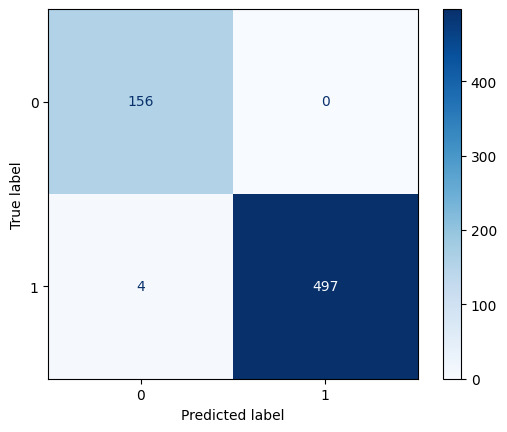

In [39]:
y_true = data["p_np"]
y_pred = targets_pred

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [ ]:
from mother.optimization.report import optuna_qc

export_dir = Path.cwd() / "optuna_qc"
optuna_qc.plot_optuna_qc(study=tuner.study, export_dir=export_dir)

INFO:mother.optimization.report.optuna_qc:Plotting optuna results
/workspaces/mother-ml/mother/optimization/report/optuna_qc.py:33: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  axes: Axes = optuna.visualization.matplotlib.plot_optimization_history(study)
/workspaces/mother-ml/mother/optimization/report/optuna_qc.py:39: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  axes = optuna.visualization.matplotlib.plot_param_importances(
ERROR:mother.optimization.report.optuna_qc:Cannot evaluate parameter importances with only a single trial.
/workspaces/mother-ml/mother/optimization/report/optuna_qc.py:52: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  axis = optuna.visualization.matplotlib.plot_slice(study)
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/op

## Hyperparameter Optimization with nested CV
When we optimize the hyperparameters, we use a cross validation approach. Based on performance in the cross validations we choose the best set of hyperparameters. The selection of the best hyperparameters is based on the full data, so we do not really evaluate the tuning process itself. 

To properly evaluate the performance of the tuning we need to include the hyperparameter tuning in the evaluation too. 

For this we make use of a nested cross validation.

In [43]:
# make an outer cv split to be used for the outer cross validation
cv_outer = KFold(n_splits=2, random_state=42, shuffle=True)

# now run the nested cross validation with tuning in the inner fold
cv_table: pd.DataFrame = mother_takes_care.mother_cv(
    model,
    tuner=tuner,
    inner_cv=cv,
    cv=cv_outer,
    groups=groups["tanimoto-group"],
    X=features,
    y=data["p_np"],
)
cv_table

INFO:mother.pipeline_utils:Starting cross validation...
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:91: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: 2
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-b5991de1-794f-4167-8db6-b2c5d934736a
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/sit

{'ml_model__C': 1.0}


/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
INFO:mother.optimization.core:Training completed
INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: 2
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-15b707cc-5b6d-4775-bd20-8da56c97faf9
INFO:mother.optimization.core:Running hyperparameter optimization with 1 trials
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(

{'ml_model__C': 1.0}


/workspaces/mother-ml/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
INFO:mother.optimization.core:Training completed
INFO:mother.pipeline_utils:Cross validation completed


,pred_p_np,pred__proba_0,pred__proba_1,p_np,cv_group,iteration,test_index
0,1,0.006123,0.993877,1,0,0,0
1,1,0.003323,0.996677,1,1,1,1
2,1,0.006123,0.993877,1,0,0,2
3,1,0.001531,0.998469,1,2,1,3
4,1,0.001485,0.998515,1,2,1,4
...,...,...,...,...,...,...,...
652,1,0.100456,0.899544,1,270,0,652
653,1,0.153658,0.846342,1,271,0,653
654,1,0.01065,0.98935,1,263,1,654
655,1,0.000965,0.999035,1,272,1,655
